In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

R^2 =  0.8956794167563829


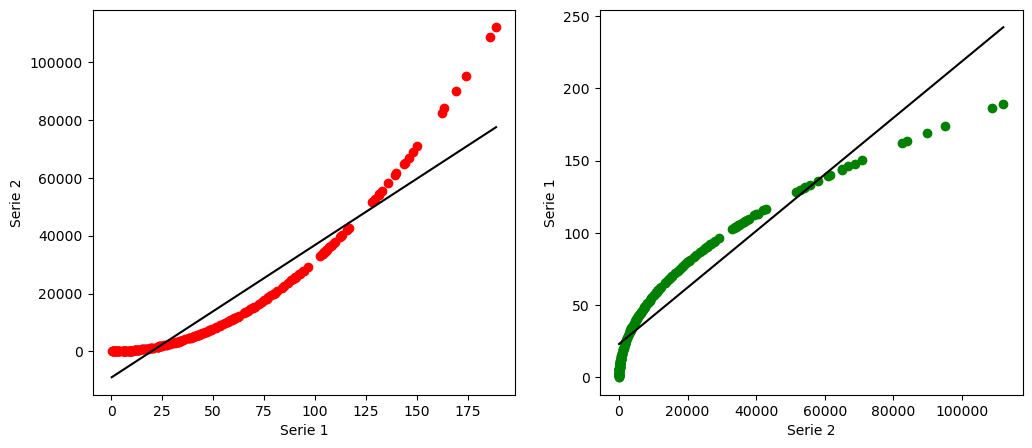

In [85]:
#Extracción de los datos
df = pd.read_excel('SeriesMarcianas.xlsx', usecols=(1, 2))
C1 = df["serie1"]
C2=df['serie2']

#Coeficientes B_0 y B_1 /
#Ba = Coeficientes con  Eje x = Serie 1
#Bb = Coeficientes con  Eje x = Serie 2
#R^2 es el mismo para ambos casos
M_1 = np.cov(C1, C2)
Ba_1 = M_1[0, 1] / M_1[0, 0]
Ba_0 = np.mean(C2) - (Ba_1*np.mean(C1))
R2 = np.square(M_1[0, 1]) / (M_1[0, 0]*M_1[1,1])
Bb_1 = M_1[0, 1] / M_1[1, 1]
Bb_0 = np.mean(C1) - (Bb_1*np.mean(C2))

#Graficar
S1 = np.linspace(C1.min(), C1.max(), 203)
S2 = np.linspace(C2.min(), C2.max(), 203)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(C1, C2, color='red')
axs[0].plot(S1, Ba_0 + (Ba_1*S1), color='black')
axs[0].set_xlabel('Serie 1')
axs[0].set_ylabel('Serie 2')
axs[1].scatter(C2, C1, color='green')
axs[1].plot(S2, Bb_0 + (Bb_1*S2), color='black')
axs[1].set_xlabel('Serie 2')
axs[1].set_ylabel('Serie 1')
print("R^2 = ", R2)
plt.show()



Al graficar los datos crudos, es difícil apreciar cual de las dos series es la variable dependiente. Pero si notamos que hay un comportamiento logarítmico -o exponencial-. Por lo tanto, sería ideal ver los datos usando una transformacion logarítmica. 

R^2 para la fila 1:  0.44549367132177226 
R^2 para la fila 2:  0.7045348742207868


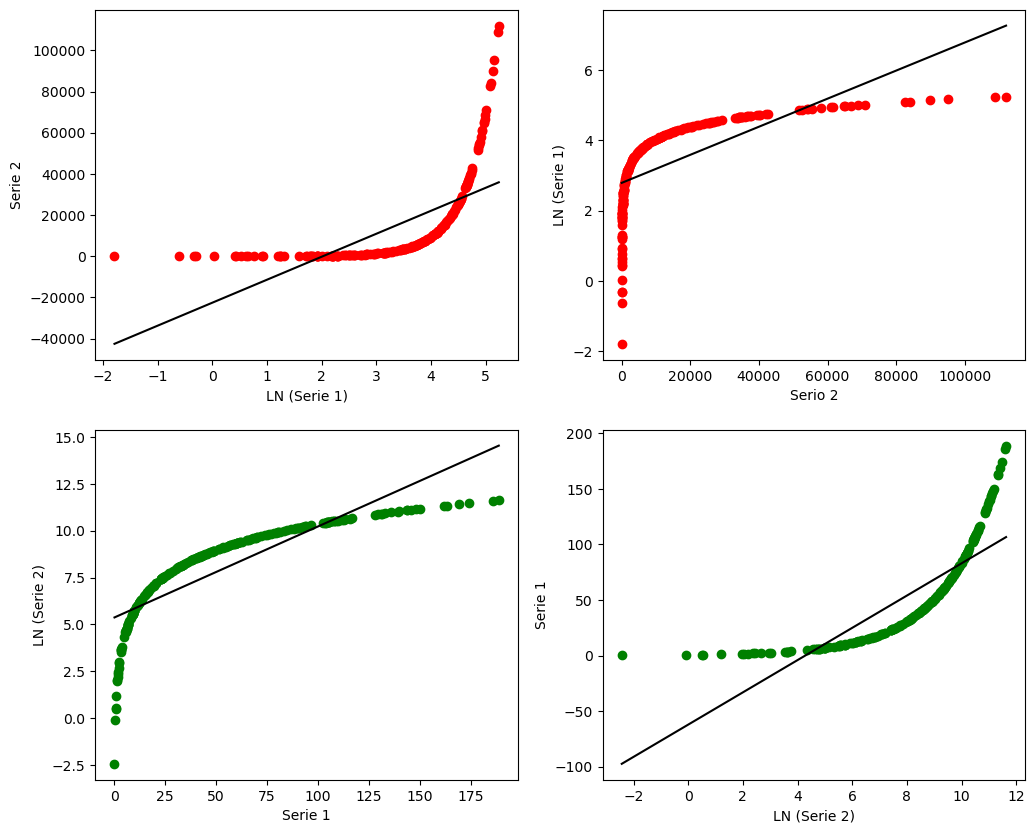

In [86]:
df = pd.read_excel('SeriesMarcianas.xlsx', usecols=(1, 2))
C1_crudo = df["serie1"]
C2_crudo = df['serie2']
C1_ln = np.log(C1_crudo)
C2_ln = np.log(C2_crudo)

M_1 = np.cov(C1_ln, C2_crudo)
B11_1 = M_1[0, 1] / M_1[0, 0]
B11_0 = np.mean(C2_crudo) - (B11_1*np.mean(C1_ln))
R2_1 = np.square(M_1[0, 1]) / (M_1[0, 0]*M_1[1, 1])

B12_1 = M_1[0, 1] / M_1[1, 1]
B12_0 = np.mean(C1_ln) - (B12_1*np.mean(C2_crudo))

M_2 = np.cov(C1_crudo, C2_ln)
B21_1 = M_2[0, 1] / M_2[0, 0]
B21_0 = np.mean(C2_ln) - (B21_1*np.mean(C1_crudo))
R2_2 = np.square(M_2[0, 1]) / (M_2[0, 0]*M_2[1, 1])

B22_1 = M_2[0, 1] / M_2[1, 1]
B22_0 = np.mean(C1_crudo) - (B22_1*np.mean(C2_ln))

#Graficar
S_C1_ln = np.linspace(C1_ln.min(), C1_ln.max(), 203)
S_C2_crudo = np.linspace(C2_crudo.min(), C2_crudo.max(), 203)
S_C1_crudo = np.linspace(C1_crudo.min(), C1_crudo.max(), 203)
S_C2_ln = np.linspace(C2_ln.min(), C2_ln.max(), 203)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].scatter(C1_ln, C2_crudo, color='red')
axs[0, 0].plot(S_C1_ln, B11_0 + (B11_1*S_C1_ln), color='black')
axs[0, 0].set_xlabel('LN (Serie 1)')
axs[0, 0].set_ylabel('Serie 2')

axs[0, 1].scatter(C2_crudo, C1_ln, color='red')
axs[0, 1].plot(S_C2_crudo, B12_0 + (B12_1*S_C2_crudo), color='black')
axs[0, 1].set_xlabel('Serio 2')
axs[0, 1].set_ylabel('LN (Serie 1)')

axs[1, 0].scatter(C1_crudo, C2_ln, color='green')
axs[1, 0].plot(S_C1_crudo, B21_0 + (B21_1*S_C1_crudo), color='black')
axs[1, 0].set_xlabel('Serie 1')
axs[1, 0].set_ylabel('LN (Serie 2)')

axs[1, 1].scatter(C2_ln, C1_crudo, color='green')
axs[1, 1].plot(S_C2_ln, B22_0 + (B22_1*S_C2_ln), color='black')
axs[1, 1].set_xlabel('LN (Serie 2)')
axs[1, 1].set_ylabel('Serie 1')
print('R^2 para la fila 1: ', R2_1, "\nR^2 para la fila 2: ", R2_2)
plt.show()

Notamos que la recta de regresión ahora es incluso más imprecisa que con los datos crudos. Pero, además, es evidente que hay una relación exponencial entre los datos de ambas series, por lo que será necesario aplicar una transformación de LN a ambas series y no solo a una.

R^2 =  1.0
B1_0 =  1.1447298858494 
B1_1 =  2.0
B2_0 =  -0.5723649429247 
B2_1 =  0.5


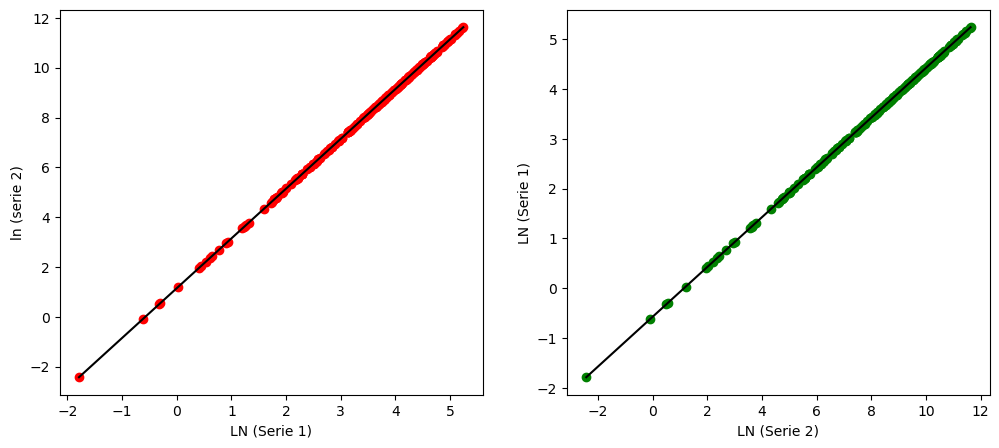

In [87]:
#Extracción de los datos
df = pd.read_excel('SeriesMarcianas.xlsx', usecols=(1, 2))
C1 = np.log(df["serie1"])
C2=np.log(df['serie2'])

#Coeficientes B_0 y B_1 /
#Ba = Coeficientes con  Eje x = LN(Serie 1)
#Bb = Coeficientes con  Eje x = LN(Serie 2)
#R^2 es el mismo para ambos casos
M_1 = np.cov(C1, C2)
Ba_1 = M_1[0, 1] / M_1[0, 0]
Ba_0 = np.mean(C2) - (Ba_1*np.mean(C1))
R2 = np.square(M_1[0, 1]) / (M_1[0, 0]*M_1[1,1])
Bb_1 = M_1[0, 1] / M_1[1, 1]
Bb_0 = np.mean(C1) - (Bb_1*np.mean(C2))

#Graficar
S1 = np.linspace(C1.min(), C1.max(), 203)
S2 = np.linspace(C2.min(), C2.max(), 203)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(C1, C2, color='red')
axs[0].plot(S1, Ba_0 + (Ba_1*S1), color='black')
axs[0].set_xlabel('LN (Serie 1)')
axs[0].set_ylabel('ln (serie 2)')
axs[1].scatter(C2, C1, color='green')
axs[1].plot(S2, Bb_0 + (Bb_1*S2), color='black')
axs[1].set_xlabel('LN (Serie 2)')
axs[1].set_ylabel('LN (Serie 1)')
print("R^2 = ", R2)
print('B1_0 = ', Ba_0, "\nB1_1 = ", Ba_1)
print('B2_0 = ', Bb_0, "\nB2_1 = ", Bb_1)
plt.show()

Con esto notamos, finalmente, que los datos están estrictamente correlacionados.

Al tener un  $R^2 = 1$, es evidente que $SCE = SCT$, por lo tanto la recta de regresión explica perfectamente el comportamiento de los datos.

La cuestión ahora es saber cuál es la serie dependiente y cuál la independiente. Honestamente, no sé cómo decidir sobre cuál es la correcta así que mejor dejar la desición a la suerte:

In [88]:
def lanzamiento_moneda():
    a=np.random.random()
    if a <= 0.5:
        return "sello"
    else:
       return "águila"
if lanzamiento_moneda() == "sello":
    print('La serie 2 es la dependiente. Por tanto, la gráfica de la izquierda es la correcta')
else:
    print('La serie 1 es la dependiente. Por tanto, la gráfica de la derecha es la correcta')

La serie 2 es la dependiente. Por tanto, la gráfica de la izquierda es la correcta
